In [1]:
from pathlib import Path
DATA_DIR = Path("../../data/gamma-b")

In [2]:
import pandas as pd
df = pd.read_csv(DATA_DIR / "to_filter.tsv", delimiter="\t", low_memory=False)

In [3]:
print(df.head())
print(df.info())

  Assembly Name Assembly Accession Assembly Paired Assembly Accession  \
0      ASM694v2    GCA_000006945.2                    GCF_000006945.2   
1      ASM694v2    GCF_000006945.2                    GCA_000006945.2   
2   ASM903584v1    GCA_009035845.1                    GCF_009035845.1   
3   ASM903584v1    GCF_009035845.1                    GCA_009035845.1   
4    ASM41267v1    GCA_000412675.1                    GCF_000412675.1   

                                       Organism Name ANI Check status  \
0  Salmonella enterica subsp. enterica serovar Ty...               OK   
1  Salmonella enterica subsp. enterica serovar Ty...               OK   
2                            Acinetobacter baumannii               OK   
3                            Acinetobacter baumannii               OK   
4                      Pseudomonas putida NBRC 14164               OK   

   Organism Infraspecific Names Breed Organism Infraspecific Names Strain  \
0                                 NaN        

In [4]:
import os
print(f"Number of unique assemblies: {df['Organism Name'].nunique()}")
print(f"Number of reference assemblies: {len(os.listdir(DATA_DIR / 'reference_only'))}")

Number of unique assemblies: 5531
Number of reference assemblies: 1393


In [5]:
print(df["ANI Check status"].value_counts())

ANI Check status
OK              57104
Inconclusive     2736
Failed            157
Name: count, dtype: int64


In [6]:
df['failure_prob'] = (df['CheckM contamination'] / 100) * (1 - (df['CheckM completeness'] / 100))

df = df.sort_values('failure_prob', ascending=True)\
       .drop_duplicates(subset='Organism Name')\
       .drop(columns='failure_prob')

In [7]:
# Check that there are no duplicates
print(df["Organism Name"].nunique() - len(df["Organism Name"]))

0


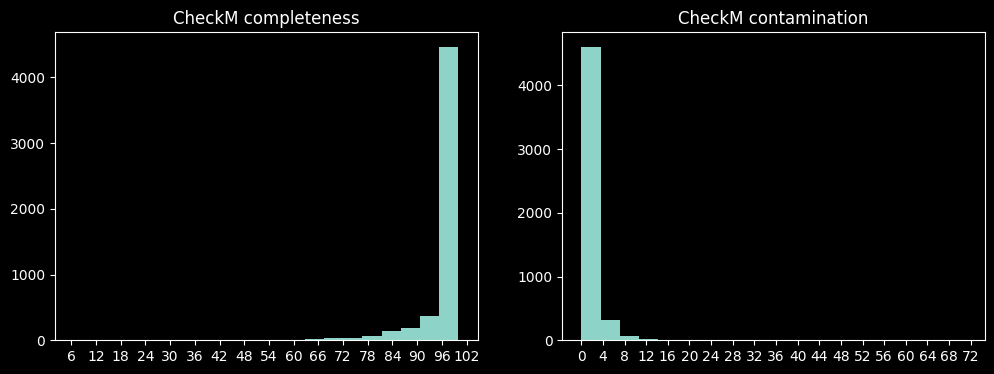

In [8]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(df["CheckM completeness"].values, bins=20)
axs[0].set_title("CheckM completeness")
axs[0].xaxis.set_major_locator(plt.MaxNLocator(20))

axs[1].hist(df["CheckM contamination"].values, bins=20)
axs[1].set_title("CheckM contamination")
axs[1].xaxis.set_major_locator(plt.MaxNLocator(20))

plt.show()

In [9]:
# Remove the ones that have completeness < 80 or contamination > 8
print(len(df))
df = df[(df["CheckM completeness"] >= 80) | (df["CheckM contamination"] <= 8)]
print(len(df))

5531
5297


In [10]:
# Store the organisms name in a txt file for downloading
out = "\n".join(df["Assembly Accession"])
with open(DATA_DIR / "to_download.txt", "w") as f:
    f.write(out)